In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/bonos_clean.csv")

In [2]:
df.shape

(773291, 19)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 773291 entries, 0 to 773290
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   COD_HOGAR            773291 non-null  int64  
 1   UBIGEO               773291 non-null  int64  
 2   DE_DEPARTAMENTO      773291 non-null  str    
 3   DE_PROVINCIA         773291 non-null  str    
 4   DE_DISTRITO          773291 non-null  str    
 5   PERSONAS_HOGAR       773291 non-null  int64  
 6   MONTO                773291 non-null  float64
 7   TIPO_BONO            773291 non-null  str    
 8   BONO_COBRADO         773291 non-null  str    
 9   FECHA_COBRO          679584 non-null  str    
 10  ENTIDAD_COBRO        773291 non-null  str    
 11  MEDIO_COBRO          773291 non-null  str    
 12  FECHA_ACTUALIZACION  773291 non-null  str    
 13  ANIO_COBRO           679584 non-null  float64
 14  MES_COBRO            679584 non-null  float64
 15  NOMBRE_MES           679584 

In [4]:
df.isnull().sum()

COD_HOGAR                  0
UBIGEO                     0
DE_DEPARTAMENTO            0
DE_PROVINCIA               0
DE_DISTRITO                0
PERSONAS_HOGAR             0
MONTO                      0
TIPO_BONO                  0
BONO_COBRADO               0
FECHA_COBRO            93707
ENTIDAD_COBRO              0
MEDIO_COBRO                0
FECHA_ACTUALIZACION        0
ANIO_COBRO             93707
MES_COBRO              93707
NOMBRE_MES             93707
TRIMESTRE_COBRO        93707
PERIODO_COBRO          93707
BONO_COBRADO_FLAG          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["MONTO"].describe()

count    773291.0
mean        760.0
std           0.0
min         760.0
25%         760.0
50%         760.0
75%         760.0
max         760.0
Name: MONTO, dtype: float64

In [7]:
df["BONO_COBRADO"].value_counts()

BONO_COBRADO
SI    679584
NO     93707
Name: count, dtype: int64

In [8]:
df["DE_DEPARTAMENTO"].nunique()

25

In [9]:
df["DE_DEPARTAMENTO"].unique()

<StringArray>
[     'AMAZONAS',     'CAJAMARCA',        'ANCASH',        'CALLAO',
      'APURIMAC',      'AREQUIPA',         'CUSCO',      'AYACUCHO',
         'JUNIN',    'SAN MARTIN',  'HUANCAVELICA',          'LIMA',
       'HUANUCO',   'LA LIBERTAD',         'PASCO',        'LORETO',
         'PIURA',          'PUNO', 'MADRE DE DIOS',    'LAMBAYEQUE',
       'UCAYALI',           'ICA',         'TACNA',      'MOQUEGUA',
        'TUMBES']
Length: 25, dtype: str

In [10]:
bonos_departamento = (
    df.groupby("DE_DEPARTAMENTO")["MONTO"]
    .sum()
    .sort_values(ascending=False)
)

bonos_departamento

DE_DEPARTAMENTO
LIMA             182963920.0
AREQUIPA          61400400.0
LA LIBERTAD       37534120.0
JUNIN             30814200.0
PIURA             26245840.0
PUNO              25942600.0
LAMBAYEQUE        25134720.0
ANCASH            21430480.0
CUSCO             18485480.0
ICA               18471800.0
SAN MARTIN        18082680.0
CAJAMARCA         17426800.0
CALLAO            16980680.0
HUANUCO           14347280.0
TACNA             12149360.0
AYACUCHO          11308800.0
LORETO             9781960.0
UCAYALI            7197960.0
MADRE DE DIOS      5880120.0
PASCO              5848200.0
MOQUEGUA           4968120.0
TUMBES             4472600.0
AMAZONAS           4282600.0
APURIMAC           3926920.0
HUANCAVELICA       2623520.0
Name: MONTO, dtype: float64

In [11]:
hogares_departamento = (
    df.groupby("DE_DEPARTAMENTO")["COD_HOGAR"]
    .nunique()
    .sort_values(ascending=False)
)

hogares_departamento

DE_DEPARTAMENTO
LIMA             240742
AREQUIPA          80790
LA LIBERTAD       49387
JUNIN             40545
PIURA             34534
PUNO              34135
LAMBAYEQUE        33072
ANCASH            28198
CUSCO             24323
ICA               24305
SAN MARTIN        23793
CAJAMARCA         22930
CALLAO            22343
HUANUCO           18878
TACNA             15986
AYACUCHO          14880
LORETO            12871
UCAYALI            9471
MADRE DE DIOS      7737
PASCO              7695
MOQUEGUA           6537
TUMBES             5885
AMAZONAS           5635
APURIMAC           5167
HUANCAVELICA       3452
Name: COD_HOGAR, dtype: int64

In [12]:
df["MONTO"].mean()

np.float64(760.0)

In [14]:
df.groupby("ENTIDAD_COBRO")["COD_HOGAR"].nunique().sort_values(
    ascending=False
)

ENTIDAD_COBRO
BANCO DE LA NACION    773291
Name: COD_HOGAR, dtype: int64

In [15]:
df["MEDIO_COBRO"].value_counts()

MEDIO_COBRO
BANCA CELULAR      513190
VENTANILLA         146652
ABONO EN CUENTA    113449
Name: count, dtype: int64

In [16]:
df["TIPO_BONO"].value_counts()

TIPO_BONO
BONO_INDEPENDIENTE    773291
Name: count, dtype: int64

In [17]:
cobros_mensuales = (
    df.groupby("PERIODO_COBRO")["COD_HOGAR"]
    .nunique()
)

cobros_mensuales

PERIODO_COBRO
2020-04    519068
2020-05    143986
2020-06     16530
Name: COD_HOGAR, dtype: int64

In [18]:
monto_mensual = (
    df.groupby("PERIODO_COBRO")["MONTO"]
    .sum()
)

monto_mensual

PERIODO_COBRO
2020-04    394491680.0
2020-05    109429360.0
2020-06     12562800.0
Name: MONTO, dtype: float64

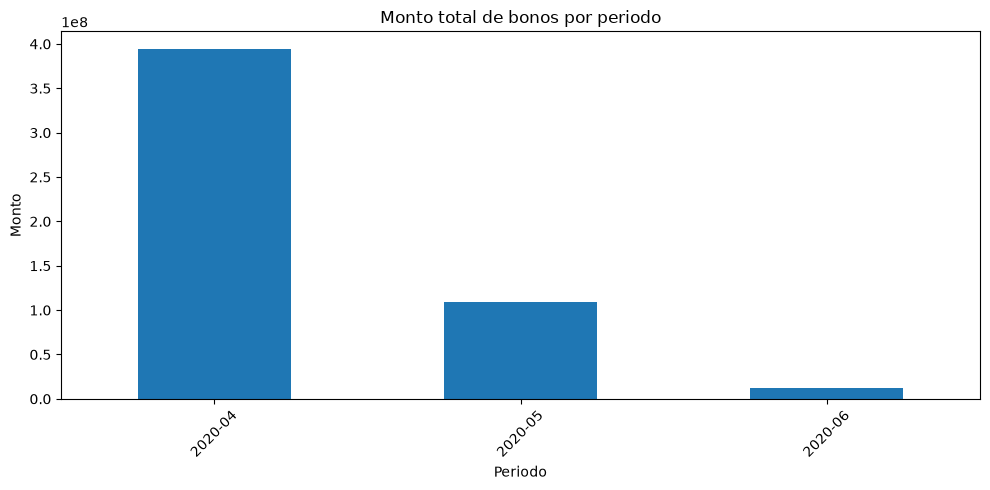

In [29]:
monto_mensual.plot(kind="bar", figsize=(10, 5))

plt.title("Monto total de bonos por periodo")
plt.xlabel("Periodo")
plt.ylabel("Monto")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

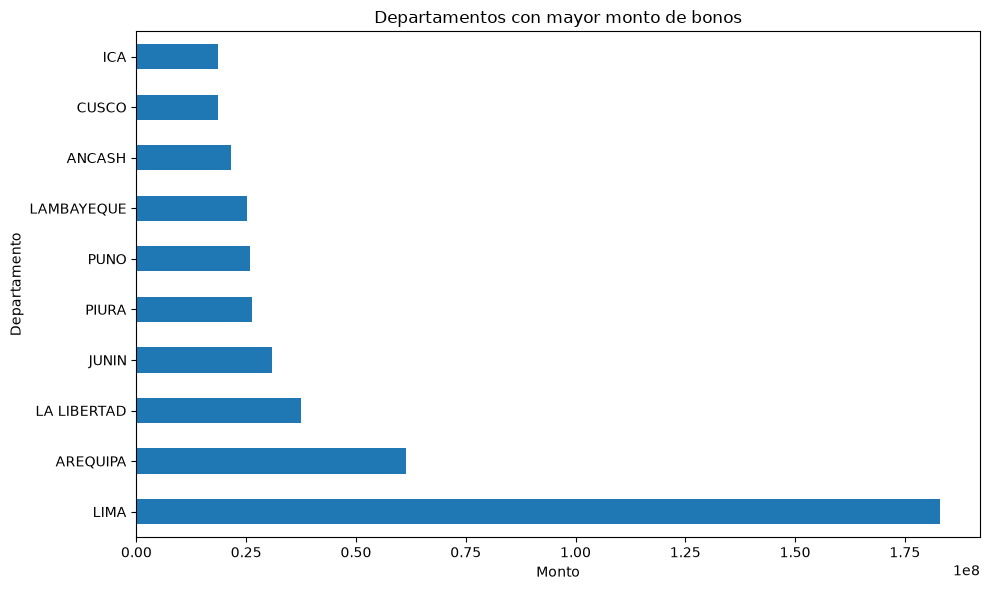

In [30]:
bonos_departamento.head(10).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Departamentos con mayor monto de bonos")
plt.xlabel("Monto")
plt.ylabel("Departamento")

plt.tight_layout()
plt.show()

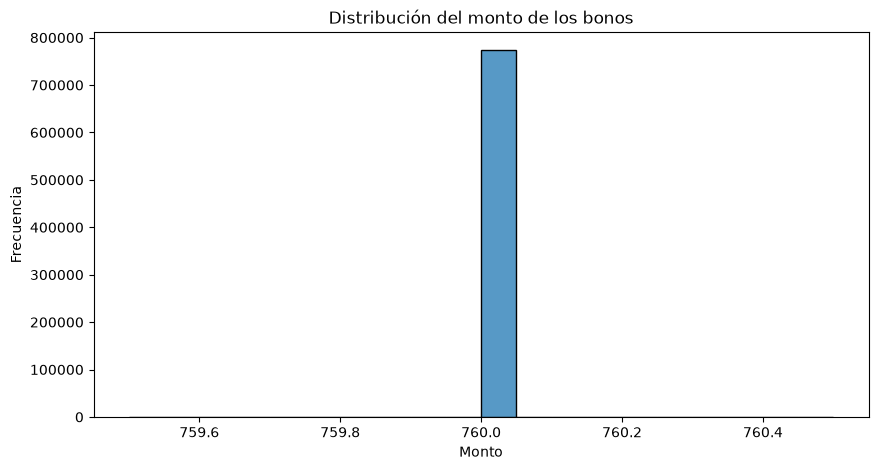

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="MONTO",
    bins=20
)

plt.title("Distribución del monto de los bonos")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.show()

In [20]:
tasa_cobro = df["BONO_COBRADO_FLAG"].mean()

tasa_cobro

np.float64(0.8788205216406243)

In [21]:
tasa_cobro * 100

np.float64(87.88205216406243)

In [22]:
tasa_cobro_departamento = (
    df.groupby("DE_DEPARTAMENTO")["BONO_COBRADO_FLAG"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

tasa_cobro_departamento

DE_DEPARTAMENTO
PUNO             93.710268
PASCO            93.307342
HUANUCO          93.182541
SAN MARTIN       92.762577
AMAZONAS         92.262644
CAJAMARCA        92.176188
AREQUIPA         92.105459
TUMBES           91.996602
AYACUCHO         91.001344
LAMBAYEQUE       90.980285
HUANCAVELICA     90.874855
JUNIN            90.862005
MADRE DE DIOS    90.732842
CUSCO            90.696049
MOQUEGUA         90.255469
PIURA            90.180691
UCAYALI          90.001056
TACNA            89.328162
APURIMAC         88.349139
ICA              88.212302
LORETO           87.895268
ANCASH           86.392652
LA LIBERTAD      85.403041
LIMA             83.074412
CALLAO           81.488609
Name: BONO_COBRADO_FLAG, dtype: float64

In [23]:
total_hogares = df["COD_HOGAR"].nunique()

total_hogares

773291

In [24]:
monto_total = df["MONTO"].sum()

monto_total

np.float64(587701160.0)

In [25]:
monto_cobrado = df.loc[
    df["BONO_COBRADO"] == "SI",
    "MONTO"
].sum()

monto_cobrado

np.float64(516483840.0)

In [26]:
monto_pendiente = df.loc[
    df["BONO_COBRADO"] != "SI",
    "MONTO"
].sum()

monto_pendiente

np.float64(71217320.0)

In [27]:
kpis = {
    "hogares_beneficiarios": df["COD_HOGAR"].nunique(),
    "monto_total": df["MONTO"].sum(),
    "monto_cobrado": df.loc[
        df["BONO_COBRADO"] == "SI", "MONTO"
    ].sum(),
    "monto_pendiente": df.loc[
        df["BONO_COBRADO"] != "SI", "MONTO"
    ].sum(),
    "tasa_cobro": df["BONO_COBRADO_FLAG"].mean()
}

kpis

{'hogares_beneficiarios': 773291,
 'monto_total': np.float64(587701160.0),
 'monto_cobrado': np.float64(516483840.0),
 'monto_pendiente': np.float64(71217320.0),
 'tasa_cobro': np.float64(0.8788205216406243)}

In [34]:
df.to_csv(
    "../data/processed/bonos_clean.csv",
    index=False,
    encoding="utf-8-sig"
)